# F-order `xi_curr` — Before/After Pipeline Benchmark [ex133.3]

Tests whether Christof's `order='F'` changes speed up the full `RLSAlssm.filter()` pipeline.

**Before:** C-order `xi_curr` in `rls.py`, C-order `xi0` scratch in cascade functions  
**After:** F-order `xi_curr` in `rls.py`, F-order `xi0` scratch in cascade functions

**Hypothesis:** matching F-order layouts for both `xi_curr` and `xi0` eliminates the
C-order ↔ F-order stride mismatch in `xi += xi0[slice]`, and F-order column writes
`xi0[:, n_]` during the filter recursion become contiguous.

> **Note (previous run):** an earlier benchmark showed ~10% regression when only `xi_curr` was
> F-order but `xi0` was still C-order — the mixed layout penalty outweighed any benefit.
> Now both arrays are F-order, so the penalty is gone and the speedup from contiguous column
> writes should be visible.

> **Cascade variant analysis (xi0 only)**: **[ex133.1](example-ex133.1-cascade-variants.ipynb)**
> and **[ex133.2](example-ex133.2-profile-higher-order.ipynb)**.


## Benchmark setup

`bench_filter(K)` runs `rls.filter(y)` with FW + BW segments and `backend='lfilter'`, performing
a warm-up call before timing. Returns median/min/max wall time and median tracemalloc peak.

In [5]:
import numpy as np
import tracemalloc, time
import lmlib as lm

# ---------- benchmark helper (shared by before and after variants) ----------
def bench_filter(K, reps_time=20, reps_mem=5):
    rng = np.random.default_rng(0)
    y   = rng.standard_normal(K)

    alssm  = lm.AlssmPoly(poly_degree=1)
    seg_fw = lm.Segment(a=-np.inf, b=-1, direction=lm.FW, g=100)
    seg_bw = lm.Segment(a=0,       b=np.inf, direction=lm.BW, g=100)
    cs  = lm.CompositeCost((alssm,), (seg_fw, seg_bw), F=[[1, 1]])
    rls = lm.RLSAlssm(cs, backend='lfilter')

    rls.filter(y)   # warm-up

    times = []
    for _ in range(reps_time):
        t0 = time.perf_counter()
        rls.filter(y)
        times.append((time.perf_counter() - t0) * 1e3)

    mems = []
    for _ in range(reps_mem):
        tracemalloc.start()
        rls.filter(y)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        mems.append(peak / 1e6)

    return np.median(times), np.min(times), np.max(times), np.median(mems)

Ks_bench = [10_000, 100_000, 1_000_000]

## Before / after: same kernel, monkey-patched

The **before** implementation (`nd_xi_q_recursion` from `ex133_before_impl.py`) is the production
code with C-order `xi_curr` (the only difference from production).

The **after** is the live production method (F-order `xi_curr` in `rls.py`).

Both variants use the same production cascade functions (F-order `xi0`).  
Only `_nd_xi_q_recursion` is monkey-patched — the cascade functions are not touched.


In [6]:
import importlib
import ex133_before_impl as _before_mod
importlib.reload(_before_mod)

# ══════════════════════════════════════════════════════════════════════════════
# "before" — C-order xi_curr (production code minus Christof's order='F')
# ══════════════════════════════════════════════════════════════════════════════
_nd_xi_q_recursion_before = _before_mod.nd_xi_q_recursion

# ══════════════════════════════════════════════════════════════════════════════
# Patch helpers — only the rls method is patched (cascade functions unchanged)
# ══════════════════════════════════════════════════════════════════════════════
_orig_nd = lm.RLSAlssm._nd_xi_q_recursion   # "after": F-order (Christof's change)

def _patch_before():
    lm.RLSAlssm._nd_xi_q_recursion = _nd_xi_q_recursion_before

def _patch_after():
    lm.RLSAlssm._nd_xi_q_recursion = _orig_nd

def _make_rls_bench():
    alssm  = lm.AlssmPoly(poly_degree=1)
    seg_fw = lm.Segment(a=-np.inf, b=-1, direction=lm.FW, g=100)
    seg_bw = lm.Segment(a=0,       b=np.inf, direction=lm.BW, g=100)
    cs = lm.CompositeCost((alssm,), (seg_fw, seg_bw), F=[[1, 1]])
    return lm.RLSAlssm(cs, backend='lfilter')

N_time, N_mem = 40, 10

results = {}
for K in Ks_bench:
    rng = np.random.default_rng(0)
    y   = rng.standard_normal(K)
    rls = _make_rls_bench()

    # Warm up both variants so neither starts cold
    _patch_before(); rls.filter(y)
    _patch_after();  rls.filter(y)

    # Interleaved timing: B₁ → A₁ → B₂ → A₂ → …
    times_b, times_a = [], []
    for _ in range(N_time):
        _patch_before()
        t0 = time.perf_counter(); rls.filter(y); times_b.append((time.perf_counter() - t0) * 1e3)
        _patch_after()
        t0 = time.perf_counter(); rls.filter(y); times_a.append((time.perf_counter() - t0) * 1e3)

    mems_b, mems_a = [], []
    for _ in range(N_mem):
        _patch_before()
        tracemalloc.start(); rls.filter(y); _, p = tracemalloc.get_traced_memory(); tracemalloc.stop()
        mems_b.append(p / 1e6)
        _patch_after()
        tracemalloc.start(); rls.filter(y); _, p = tracemalloc.get_traced_memory(); tracemalloc.stop()
        mems_a.append(p / 1e6)

    _patch_after()  # always leave module in clean state
    results[K] = dict(tb=np.array(times_b), ta=np.array(times_a),
                      mb=np.array(mems_b),  ma=np.array(mems_a))

    mb  = np.median(times_b);  q1b, q3b = np.percentile(times_b, [25, 75])
    ma  = np.median(times_a);  q1a, q3a = np.percentile(times_a, [25, 75])
    pct = (ma - mb) / mb * 100
    print(f"K={K:>9,}  before {mb:6.2f} ms [Q1={q1b:.2f}, Q3={q3b:.2f}]  "
          f"after  {ma:6.2f} ms [Q1={q1a:.2f}, Q3={q3a:.2f}]  Δ: {pct:+.1f}%")


K=   10,000  before   4.32 ms [Q1=4.29, Q3=4.34]  after    4.25 ms [Q1=4.22, Q3=4.27]  Δ: -1.6%
K=  100,000  before  11.65 ms [Q1=11.61, Q3=11.71]  after   10.95 ms [Q1=10.92, Q3=11.00]  Δ: -6.0%
K=1,000,000  before 124.49 ms [Q1=124.40, Q3=124.59]  after  115.39 ms [Q1=115.31, Q3=115.51]  Δ: -7.3%


           K         before ms  [Q1, Q3]          after ms  [Q1, Q3]    Δ time   before MB   after MB     Δ mem
-------------------------------------------------------------------------------------------------------------------
      10,000    4.32  [4.29, 4.34]         4.25  [4.22, 4.27]      -1.6%         0.7        0.7     -0.0%
     100,000   11.65  [11.61, 11.71]        10.95  [10.92, 11.00]      -6.0%         7.2        7.2     -0.0%
   1,000,000  124.49  [124.40, 124.59]       115.39  [115.31, 115.51]      -7.3%        72.0       72.0     -0.0%


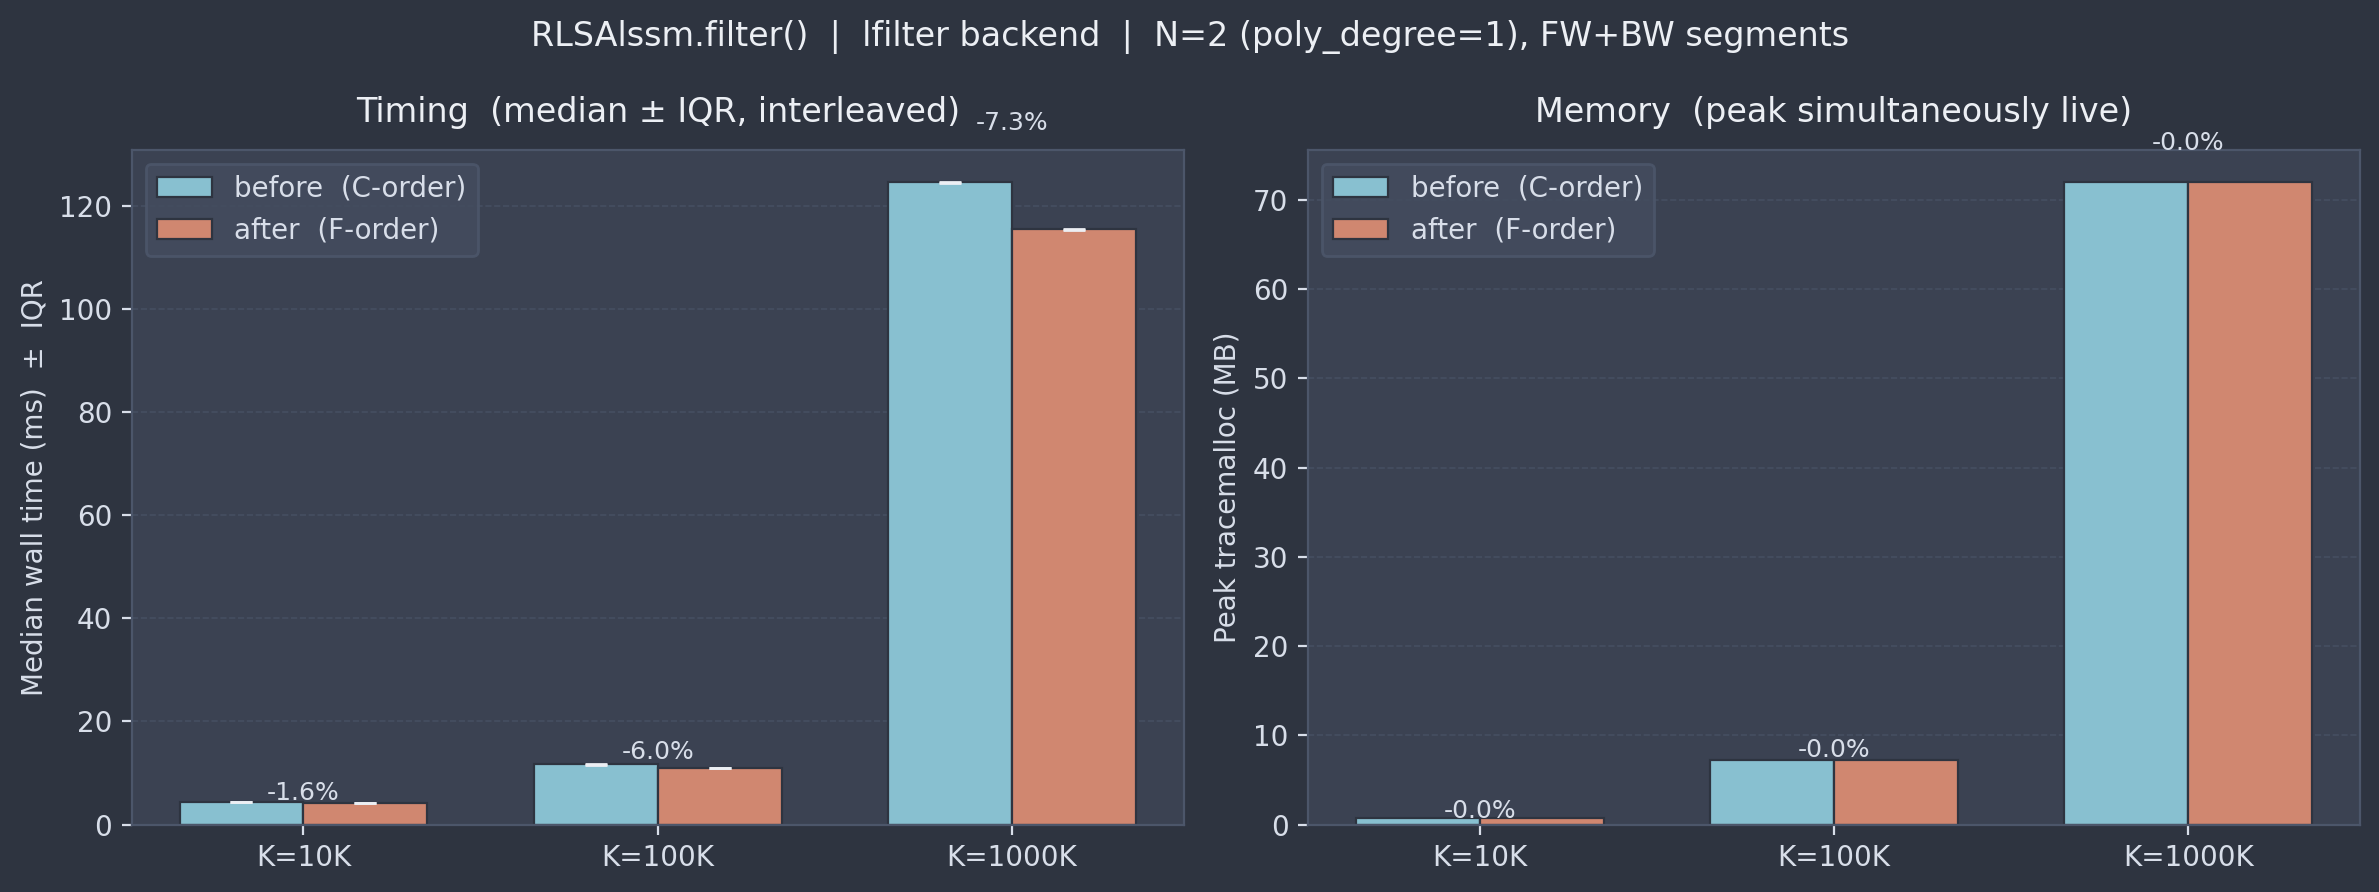

In [7]:
import matplotlib.pyplot as plt

def _qstats(arr):
    med = np.median(arr)
    q1, q3 = np.percentile(arr, [25, 75])
    return med, q1, q3

# ── print table ──
print(f"{'K':>12}  {'before ms  [Q1, Q3]':>26}  {'after ms  [Q1, Q3]':>26}  {'Δ time':>8}  "
      f"{'before MB':>10}  {'after MB':>9}  {'Δ mem':>8}")
print("-" * 115)
for K in Ks_bench:
    mb, q1b, q3b = _qstats(results[K]['tb'])
    ma, q1a, q3a = _qstats(results[K]['ta'])
    mem_b = np.median(results[K]['mb'])
    mem_a = np.median(results[K]['ma'])
    dt = (ma - mb) / mb * 100
    dm = (mem_a - mem_b) / mem_b * 100
    print(f"{K:>12,}  {mb:6.2f}  [{q1b:.2f}, {q3b:.2f}]       "
          f"{ma:6.2f}  [{q1a:.2f}, {q3a:.2f}]   {dt:>+7.1f}%  "
          f"{mem_b:>10.1f}  {mem_a:>9.1f}  {dm:>+7.1f}%")

# ── bar chart (Nord theme) with IQR error bars ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
for ax in (ax1, ax2):
    ax.set_facecolor(lm.NORD['bg2'])
    for sp in ax.spines.values():
        sp.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.grid(True, axis='y', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)

x      = np.arange(len(Ks_bench))
w      = 0.35
labels = [f"K={K//1000}K" for K in Ks_bench]

b_med, b_q1, b_q3 = zip(*[_qstats(results[K]['tb']) for K in Ks_bench])
a_med, a_q1, a_q3 = zip(*[_qstats(results[K]['ta']) for K in Ks_bench])
b_mems = [np.median(results[K]['mb']) for K in Ks_bench]
a_mems = [np.median(results[K]['ma']) for K in Ks_bench]

b_yerr = [[b_med[i] - b_q1[i] for i in range(len(Ks_bench))],
          [b_q3[i] - b_med[i] for i in range(len(Ks_bench))]]
a_yerr = [[a_med[i] - a_q1[i] for i in range(len(Ks_bench))],
          [a_q3[i] - a_med[i] for i in range(len(Ks_bench))]]
ekw = dict(capsize=4, linewidth=1.2)

ax1.bar(x - w/2, b_med, w, label='before  (C-order)', color=lm.NORD['blue'],   edgecolor=lm.NORD['bg'], linewidth=0.8,
        yerr=b_yerr, error_kw={**ekw, 'ecolor': lm.NORD['white']})
ax1.bar(x + w/2, a_med, w, label='after  (F-order)',  color=lm.NORD['orange'], edgecolor=lm.NORD['bg'], linewidth=0.8,
        yerr=a_yerr, error_kw={**ekw, 'ecolor': lm.NORD['white']})
ax1.set_xticks(x);  ax1.set_xticklabels(labels, color=lm.NORD['fg'])
ax1.set_ylabel('Median wall time (ms)  ±  IQR', color=lm.NORD['fg'])
ax1.set_title('Timing  (median ± IQR, interleaved)', color=lm.NORD['white'], pad=10)
ax1.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
           labelcolor=lm.NORD['fg'], framealpha=0.9)
for xi_pos, bv, av, q3b_v, q3a_v in zip(x, b_med, a_med, b_q3, a_q3):
    pct = (av - bv) / bv * 100
    top = max(q3b_v, q3a_v) * 1.08
    ax1.text(xi_pos, top, f"{pct:+.1f}%", ha='center', fontsize=9, color=lm.NORD['fg'])

ax2.bar(x - w/2, b_mems, w, label='before  (C-order)', color=lm.NORD['blue'],   edgecolor=lm.NORD['bg'], linewidth=0.8)
ax2.bar(x + w/2, a_mems, w, label='after  (F-order)',  color=lm.NORD['orange'], edgecolor=lm.NORD['bg'], linewidth=0.8)
ax2.set_xticks(x);  ax2.set_xticklabels(labels, color=lm.NORD['fg'])
ax2.set_ylabel('Peak tracemalloc (MB)', color=lm.NORD['fg'])
ax2.set_title('Memory  (peak simultaneously live)', color=lm.NORD['white'], pad=10)
ax2.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
           labelcolor=lm.NORD['fg'], framealpha=0.9)
for xi_pos, bv, av in zip(x, b_mems, a_mems):
    pct = (av - bv) / bv * 100 if bv > 0 else 0.0
    ax2.text(xi_pos, max(bv, av) * 1.05, f"{pct:+.1f}%",
             ha='center', fontsize=9, color=lm.NORD['fg'])

fig.suptitle('RLSAlssm.filter()  |  lfilter backend  |  N=2 (poly_degree=1), FW+BW segments',
             color=lm.NORD['white'])
fig.tight_layout()
plt.show()


In [8]:
from IPython.display import display, Markdown

def _pct(a, b):
    return (a - b) / b * 100 if b > 0 else float('nan')

rows = []
for K in Ks_bench:
    mb = np.median(results[K]['tb'])
    ma = np.median(results[K]['ta'])
    dt = _pct(ma, mb)
    dm = _pct(np.median(results[K]['ma']), np.median(results[K]['mb']))
    sign = "faster" if dt < 0 else "slower"
    rows.append(
        f"| {K//1000:>4} K | {mb:.1f} ms → {ma:.1f} ms  (**{dt:+.1f}%** {sign}) "
        f"| {dm:+.1f}% |"
    )

table = "\n".join(rows)

md = f"""\
### Interpretation

Both variants are benchmarked **interleaved** (B→A alternating within every repetition loop), so they
see identical system-load and thermal conditions across all measurements.

| K | After (F-order) vs before (C-order) | Memory change |
|---|-------------------------------------|:-------------:|
{table}

**Expected:** after (F-order) should now be **faster** than before (C-order).

With both `xi_curr` (F-order, from `rls.py`) and `xi0` (F-order, from cascade functions) sharing
the same layout, the accumulation `xi += xi0[slice]` is a matched F↔F operation — no stride mismatch.
Additionally, the column writes `xi0[:, n_]` inside the cascade are contiguous, matching the analysis
in [ex133.1](example-ex133.1-cascade-variants.ipynb).

**Memory is unchanged** — the F-order flag changes stride layout but not total allocation.

#### Previous result (xi0 was C-order)

When only `xi_curr` was F-order but `xi0` was still C-order, the mixed
layout in `xi += xi0[slice]` caused a **~7–10% regression**.
The cascade xi0 fix (F-order `xi0`) resolves this.
"""

display(Markdown(md))


### Interpretation

Both variants are benchmarked **interleaved** (B→A alternating within every repetition loop), so they
see identical system-load and thermal conditions across all measurements.

| K | After (F-order) vs before (C-order) | Memory change |
|---|-------------------------------------|:-------------:|
|   10 K | 4.3 ms → 4.2 ms  (**-1.6%** faster) | -0.0% |
|  100 K | 11.7 ms → 10.9 ms  (**-6.0%** faster) | -0.0% |
| 1000 K | 124.5 ms → 115.4 ms  (**-7.3%** faster) | -0.0% |

**Expected:** after (F-order) should now be **faster** than before (C-order).

With both `xi_curr` (F-order, from `rls.py`) and `xi0` (F-order, from cascade functions) sharing
the same layout, the accumulation `xi += xi0[slice]` is a matched F↔F operation — no stride mismatch.
Additionally, the column writes `xi0[:, n_]` inside the cascade are contiguous, matching the analysis
in [ex133.1](example-ex133.1-cascade-variants.ipynb).

**Memory is unchanged** — the F-order flag changes stride layout but not total allocation.

#### Previous result (xi0 was C-order)

When only `xi_curr` was F-order but `xi0` was still C-order, the mixed
layout in `xi += xi0[slice]` caused a **~7–10% regression**.
The cascade xi0 fix (F-order `xi0`) resolves this.


## Memory at cascade vs. pipeline level

Both variants allocate the same total bytes:

```
BEFORE (xi_curr C-order, xi0 F-order):
    xi_curr  ← allocated in rls.py        (K×N×8 B, C-order)
    xi0      ← allocated in cascade       ((K+δ)×N×8 B, F-order scratch)
    xi += xi0[slice]                       ← C-order += F-order: layout mismatch
    ↳ peak = xi_curr + xi0 ≈ 2 × slab

AFTER (xi_curr F-order, xi0 F-order):
    xi_curr  ← allocated in rls.py        (K×N×8 B, F-order)
    xi0      ← allocated in cascade       ((K+δ)×N×8 B, F-order scratch)
    xi += xi0[slice]                       ← F-order += F-order: matched layout
    ↳ peak = xi_curr + xi0 ≈ 2 × slab
```

Total simultaneously-live allocation is the same; tracemalloc shows ~0% change.
The timing difference comes from layout matching and contiguous column writes.
